In [1]:
import os
import collections
import numpy as np
from numpy.lib.format import open_memmap
from pathlib import Path
from tqdm import tqdm
import openwakeword
import openwakeword.data
import openwakeword.utils
import openwakeword.metrics
from openwakeword.utils import download_models
import scipy
import datasets
import matplotlib.pyplot as plt
import torch
from torch import nn
import IPython.display as ipd
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split


INFO:speechbrain.utils.quirks:Applied quirks (see `speechbrain.utils.quirks`): [allow_tf32, disable_jit_profiling]
INFO:speechbrain.utils.quirks:Excluded quirks specified by the `SB_DISABLE_QUIRKS` environment (comma-separated list): []
INFO:datasets:PyTorch version 2.5.1 available.


In [2]:
import os
#list current directory
os.listdir()
os.getcwd()
F = openwakeword.utils.AudioFeatures(melspec_model_path="C:\Mydata\DL-WakeWord/models/melspectrogram.onnx", embedding_model_path="C:\Mydata\DL-WakeWord/models/embedding_model.onnx")

In [63]:
# Load the data prepared in previous steps (it's small enough to load entirely in memory)

negative_features = np.load("negative_features.npy")
positive_features = np.load("positive_features.npy")

X = np.vstack((negative_features, positive_features))
y = np.array([0]*len(negative_features) + [1]*len(positive_features)).astype(np.float32)[...,None]

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

# Create PyTorch DataLoaders for training and testing
batch_size = 512

# Convert NumPy arrays to PyTorch tensors
train_dataset = torch.utils.data.TensorDataset(
    torch.from_numpy(X_train), torch.from_numpy(y_train)
)
test_dataset = torch.utils.data.TensorDataset(
    torch.from_numpy(X_test), torch.from_numpy(y_test)
)

training_data = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
testing_data = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Define fully-connected network in PyTorch

layer_dim = 32
fcn = nn.Sequential(
    nn.Flatten(),
    nn.Linear(X.shape[1] * X.shape[2], layer_dim),  # since the input is flattened, it's timesteps*feature columns
    nn.LayerNorm(layer_dim),
    nn.ReLU(),
    nn.Linear(layer_dim, layer_dim),
    nn.LayerNorm(layer_dim),
    nn.ReLU(),
    nn.Linear(layer_dim, 1),
    nn.Sigmoid(),
)

loss_function = torch.nn.functional.binary_cross_entropy
optimizer = torch.optim.Adam(fcn.parameters(), lr=0.001)

Training set size: 5160
Testing set size: 1291


In [62]:
del history
del fcn

In [64]:
import collections
import torch
from tqdm import tqdm
from time import time

n_epochs = 100
history = collections.defaultdict(list)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for epoch in tqdm(range(n_epochs), total=n_epochs):
    start_time = time()
    fcn.train()
    epoch_train_loss = 0
    epoch_tp, epoch_fp, epoch_fn = 0, 0, 0

    for batch in training_data:
        x, y = batch[0].to(device), batch[1].to(device)

        # Get weights for classes, assign 10x higher weight to negatives
        weights = torch.ones(y.shape[0], device=device)
        weights[y.flatten() == 1] = 0.1

        # Zero gradients
        optimizer.zero_grad()

        # Forward pass
        predictions = fcn(x)

        # Compute loss and backpropagate
        loss = loss_function(predictions, y, weights[..., None])
        loss.backward()
        optimizer.step()

        # Accumulate epoch loss
        epoch_train_loss += loss.item()

        # Compute training metrics
        pred_labels = (predictions.flatten() >= 0.5).float()
        true_labels = y.flatten()

        epoch_tp += torch.sum((pred_labels == 1) & (true_labels == 1)).item()
        epoch_fp += torch.sum((pred_labels == 1) & (true_labels == 0)).item()
        epoch_fn += torch.sum((pred_labels == 0) & (true_labels == 1)).item()

    # Calculate epoch-level averages
    epoch_train_loss /= len(training_data)
    epoch_recall = epoch_tp / (epoch_tp + epoch_fn) if (epoch_tp + epoch_fn) > 0 else 0
    epoch_precision = epoch_tp / (epoch_tp + epoch_fp) if (epoch_tp + epoch_fp) > 0 else 0
    epoch_f1 = 2 * (epoch_precision * epoch_recall) / (epoch_precision + epoch_recall) if (epoch_precision + epoch_recall) > 0 else 0

    # Append aggregated epoch values
    history['train_loss'].append(epoch_train_loss)
    history['train_recall'].append(epoch_recall)
    history['train_precision'].append(epoch_precision)
    history['train_f1'].append(epoch_f1)

    # Testing phase (evaluate model on test set)
    fcn.eval()
    with torch.no_grad():
        test_loss = 0
        total_tp, total_fp, total_fn = 0, 0, 0

        for batch in testing_data:
            x_test, y_test = batch[0].to(device), batch[1].to(device)

            # Run forward pass on test data
            test_predictions = fcn(x_test)
            
            # Compute test loss without class weights (optional)
            test_loss += loss_function(test_predictions, y_test).item()
            
            # Compute testing metrics
            pred_test_labels = (test_predictions.flatten() >= 0.5).float()
            true_test_labels = y_test.flatten()

            total_tp += torch.sum((pred_test_labels == 1) & (true_test_labels == 1)).item()
            total_fp += torch.sum((pred_test_labels == 1) & (true_test_labels == 0)).item()
            total_fn += torch.sum((pred_test_labels == 0) & (true_test_labels == 1)).item()

        # Average test loss after all batches
        history['test_loss'].append(test_loss / len(testing_data))

        # Calculate test recall, precision, and F1 score
        test_recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
        test_precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
        test_f1 = 2 * (test_precision * test_recall) / (test_precision + test_recall) if (test_precision + test_recall) > 0 else 0

        history['test_recall'].append(test_recall)
        history['test_precision'].append(test_precision)
        history['test_f1'].append(test_f1)

    end_time = time()
    # Print epoch summary with time tracking
    print(f"Epoch {epoch+1}/{n_epochs} | "
          f"Train Loss: {history['train_loss'][-1]:.4f} | "
          f"Train F1: {history['train_f1'][-1]:.4f} | "
          f"Test Loss: {history['test_loss'][-1]:.4f} | "
          f"Test F1: {history['test_f1'][-1]:.4f} | "
          f"Time: {end_time - start_time:.2f} sec")


  2%|▏         | 2/100 [00:00<00:17,  5.60it/s]

Epoch 1/100 | Train Loss: 0.2335 | Train F1: 0.7248 | Test Loss: 0.3564 | Test F1: 0.8265 | Time: 0.20 sec
Epoch 2/100 | Train Loss: 0.1599 | Train F1: 0.7640 | Test Loss: 0.3238 | Test F1: 0.8265 | Time: 0.17 sec


  3%|▎         | 3/100 [00:00<00:17,  5.54it/s]

Epoch 3/100 | Train Loss: 0.1276 | Train F1: 0.7640 | Test Loss: 0.2998 | Test F1: 0.8265 | Time: 0.18 sec


  5%|▌         | 5/100 [00:01<00:20,  4.68it/s]

...

Epoch 97/100 | Train Loss: 0.0005 | Train F1: 0.9996 | Test Loss: 0.0071 | Test F1: 0.9954 | Time: 0.19 sec


 99%|█████████▉| 99/100 [00:19<00:00,  5.05it/s]

Epoch 98/100 | Train Loss: 0.0005 | Train F1: 0.9996 | Test Loss: 0.0071 | Test F1: 0.9954 | Time: 0.21 sec
Epoch 99/100 | Train Loss: 0.0005 | Train F1: 0.9996 | Test Loss: 0.0071 | Test F1: 0.9954 | Time: 0.19 sec


100%|██████████| 100/100 [00:19<00:00,  5.08it/s]

Epoch 100/100 | Train Loss: 0.0005 | Train F1: 0.9996 | Test Loss: 0.0069 | Test F1: 0.9970 | Time: 0.21 sec


In [51]:
len(history['train_f1'])


100

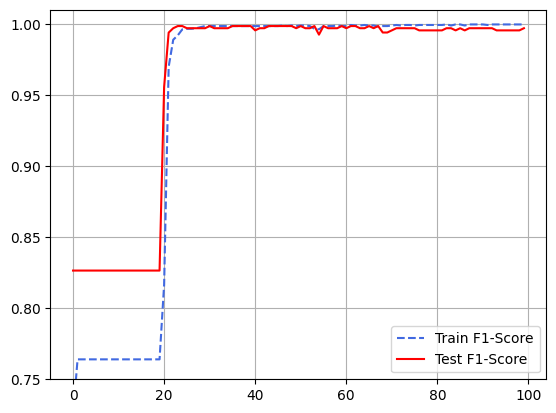

In [66]:
# Plot metrics

plt.figure()
plt.plot(history['train_f1'], label="Train F1-Score", color='royalblue',linestyle='--')
plt.plot(history['test_f1'], label="Test F1-Score", color='red')
plt.legend()
plt.ylim(0.75,1.01)
plt.grid(True)
plt.show()

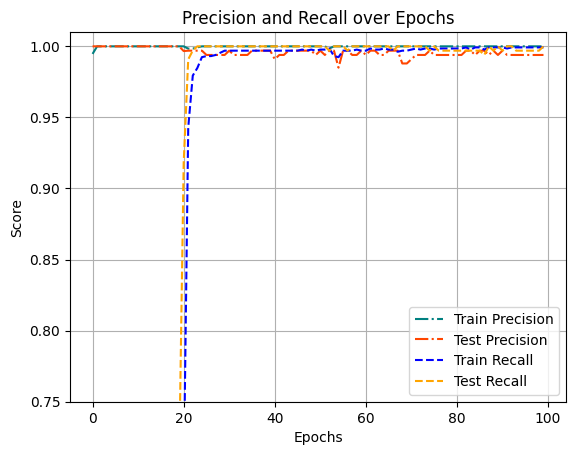

In [67]:
# Plot metrics
plt.figure()
plt.plot(history['train_precision'], label="Train Precision", linestyle='-.', color='teal')
plt.plot(history['test_precision'], label="Test Precision", linestyle='-.', color='orangered')
plt.plot(history['train_recall'], label="Train Recall", linestyle='dashed', color='blue')
plt.plot(history['test_recall'], label="Test Recall", linestyle='dashed', color='orange')
plt.legend()
plt.ylim(0.75, 1.01)
plt.title("Precision and Recall over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Score")
plt.grid(True)
plt.show()

(0.0, 0.65)

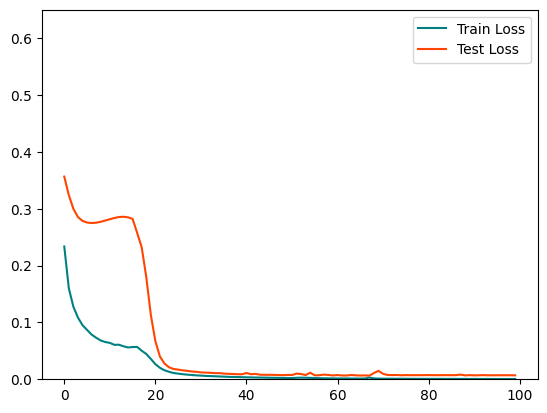

In [69]:
# Plot metrics

plt.figure()
plt.plot(history['train_loss'], label="Train Loss", color='teal')
plt.plot(history['test_loss'], label="Test Loss", color='orangered')
plt.legend()
plt.ylim(0,0.65)